[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/precourse_notebook.ipynb)

# Did the cerebellar stimulation design hit its target?

### A short Bayesian analysis

A recent methodological study designed focal tDCS montages intended to deliver approximately **0.20 V/m** to several brain targets. **P6** targets the **right cerebellum (Crus I / lobule VI)** for an eyeblink-conditioning project.

The montage was designed using one MRI sample and then evaluated in a new sample of **53 participants**.

Our question is simple:

> **After seeing the validation data, what should we believe about the average electric-field magnitude delivered to the P6 target?**

And a second question follows naturally:

> **Even if the group average is on target, how much variation should we expect from person to person?**

**Important:** the participant-level values used in this demonstration are synthetic. They were generated to be qualitatively consistent with the paper's reported P6 results; they are not the original study data.

## 1. Run this notebook in Colab

1. Choose **Runtime → Run all**.
2. Wait for the model to sample.
3. Look at the graphs and short numerical summaries.
4. Then come back to the controls below, change them, and choose **Runtime → Run all** again.

You do **not** need to understand the Python code to use the notebook. The course pins PyMC, modular ArviZ, and PreliZ here for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1" \
    "jinja2>=3.1.5" \
    "preliz==0.28.0"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from urllib.request import urlretrieve
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz_base as azb
import arviz_stats as azs
import arviz_plots as azp
import pymc as pm
import preliz as pz

RANDOM_SEED = 20260920
TARGET = 0.20

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-stats:", azs.__version__)
print("arviz-plots:", azp.__version__)
print("PreliZ:", pz.__version__)


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-stats: 1.3.2
arviz-plots: 1.3.1
PreliZ: 0.28.0


## 2. The data

The paper's independent validation sample contained 53 people. The synthetic values below mimic the broad features reported for P6: a center close to 0.20 V/m and relatively large inter-individual variation.

The script needs a data file. We are using `synthetic_p6_validation.csv`. If you upload a different file, just change the name below.

**To use real data later:** replace the CSV with one containing a column named `efield_v_per_m`. Nothing else in the notebook needs to change.

In [3]:

data_file = Path("synthetic_p6_validation.csv")
urlretrieve("https://raw.githubusercontent.com/opherdonchin/BayesShortCourse/main/synthetic_p6_validation.csv", data_file)


(PosixPath('synthetic_p6_validation.csv'),
 <http.client.HTTPMessage at 0x7fae58091580>)

Here we actually read the data

In [4]:
data = pd.read_csv(data_file)

data = data.dropna(subset=["efield_v_per_m"]).copy()

print(f"Available observations: {len(data)}")
data.head()


Available observations: 53


,participant_id,project,target_region,task_context,efield_v_per_m,synthetic
0,S2_01,P6,right cerebellum (Crus I / lobule VI),eyeblink conditioning,0.154495,True
1,S2_02,P6,right cerebellum (Crus I / lobule VI),eyeblink conditioning,0.160312,True
2,S2_03,P6,right cerebellum (Crus I / lobule VI),eyeblink conditioning,0.269528,True
3,S2_04,P6,right cerebellum (Crus I / lobule VI),eyeblink conditioning,0.309312,True
4,S2_05,P6,right cerebellum (Crus I / lobule VI),eyeblink conditioning,0.147333,True


## 3. Look at the observations

In [5]:
#@title Choose how much data to use
N_TO_USE = 53 #@param {type:"slider", min:5, max:53, step:1}

N_TO_USE = min(int(N_TO_USE), len(data))
y = data["efield_v_per_m"].to_numpy()[:N_TO_USE]

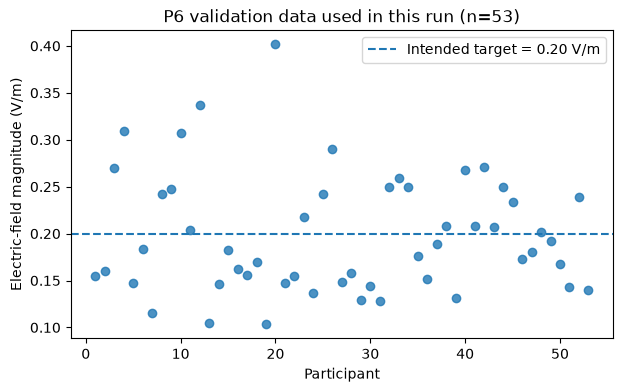

Observed mean = 0.198 V/m
Observed SD   = 0.063 V/m


In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(np.arange(1, len(y) + 1), y, alpha=0.8)
plt.axhline(TARGET, linestyle="--", label="Intended target = 0.20 V/m")
plt.xlabel("Participant")
plt.ylabel("Electric-field magnitude (V/m)")
plt.title(f"P6 validation data used in this run (n={len(y)})")
plt.legend()
plt.show()

print(f"Observed mean = {y.mean():.3f} V/m")
print(f"Observed SD   = {y.std(ddof=1):.3f} V/m")


## 4. Your assumptions before looking at the validation result

We will set our prior by answering two questions:

> **What is the lowest reasonable value for the group-average electric field?**  
> **What is the highest reasonable value for the group-average electric field?**

PreliZ finds a relatively uncommitted Normal prior with the chosen probability mass between those values.

The defaults are teaching choices. Change them after your first run.

In [7]:
#@title Prior assumptions
LOWEST_REASONABLE = 0.1 #@param {type:"slider", min:0.08, max:0.24, step:0.005}
HIGHEST_REASONABLE = 0.32 #@param {type:"slider", min:0.16, max:0.34, step:0.005}
PRIOR_MASS = "0.9" #@param [0.80, 0.90, 0.95]

if LOWEST_REASONABLE >= HIGHEST_REASONABLE:
    raise ValueError("LOWEST_REASONABLE must be below HIGHEST_REASONABLE.")






Prior for group mean: Normal(mu=0.210, sigma=0.067)
Using 53 of 53 available observations.


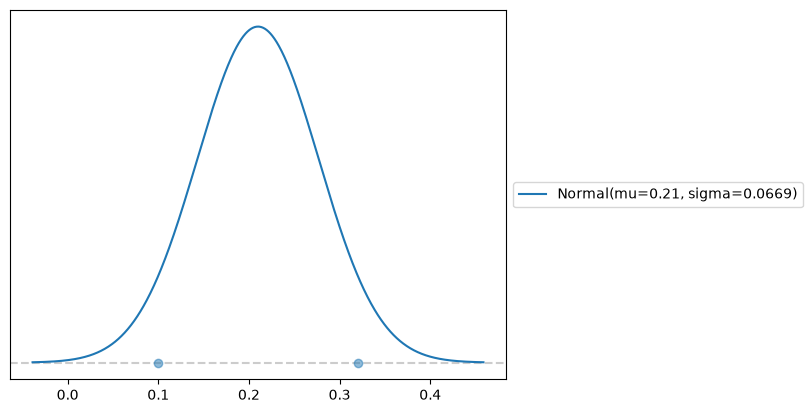

In [8]:
mu_prior = pz.Normal()
pz.maxent(
    mu_prior,
    lower=float(LOWEST_REASONABLE),
    upper=float(HIGHEST_REASONABLE),
    mass=float(PRIOR_MASS),
)

prior_mu = float(mu_prior.mu)
prior_sigma = float(mu_prior.sigma)

print(f"Prior for group mean: Normal(mu={prior_mu:.3f}, sigma={prior_sigma:.3f})")
print(f"Using {N_TO_USE} of {len(data)} available observations.")

The prior is not a claim that the true value *must* be in this interval. It says that, before looking at these validation observations, we wanted most of our prior probability to lie there.

## 5. Fit a Bayesian model

- every participant has an electric-field value,
- those values vary around an unknown group mean **μ**,
- the amount of person-to-person spread **σ** is also unknown.

PyMC draws samples from the posterior distributions of μ and σ.

In [9]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=prior_mu, sigma=prior_sigma)
    sigma = pm.HalfNormal("sigma", sigma=0.10)

    efield = pm.Normal("efield", mu=mu, sigma=sigma, observed=y)



PyMC draws samples from the posterior distributions of μ and σ.

In [10]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.90,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


### A quick computational check

For now, treat these as a **green-light check** rather than a topic to master. We want R-hat very close to 1 and reasonable effective sample sizes.

In [11]:
azs.summary(idata, var_names=["mu", "sigma"], ci_kind="hdi", ci_prob=0.90, kind='stats')


,mean,sd,hdi90_lb,hdi90_ub
mu,0.2,0.0086,0.18,0.21
sigma,0.064,0.0063,0.054,0.074


## 6. What do we believe about the group-average field strength?

The posterior below combines the prior assumptions with the validation observations. The dashed line marks the intended 0.20 V/m target; the bar under the density is the 90% HDI.


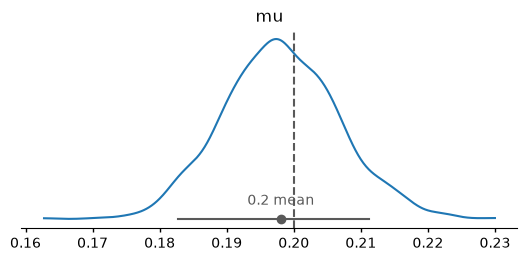

In [12]:
pc = azp.plot_dist(idata, var_names=["mu"], ci_kind="hdi", ci_prob=0.90)
azp.add_lines(pc, values=TARGET)
plt.show()


## 7. Is "close to 0.20 V/m" close enough?

The paper does not supply a scientifically justified tolerance for this teaching question. Change it to see how the scientific definition of "close enough" changes the answer.

In [13]:
#@title Illustrative practical tolerance around the 0.20 V/m target
TOLERANCE = 0.02 #@param {type:"slider", min:0.005, max:0.05, step:0.005}

rope_low = TARGET - float(TOLERANCE)
rope_high = TARGET + float(TOLERANCE)

mu_post = idata.posterior["mu"]
hdi90 = azs.hdi(mu_post, prob=0.90).values
inside = ((mu_post >= rope_low) & (mu_post <= rope_high)).mean().item()

print(f"Illustrative acceptable interval: {rope_low:.3f} to {rope_high:.3f} V/m")
print(f"90% HDI for group mean:          {hdi90[0]:.3f} to {hdi90[1]:.3f} V/m")
print(f"Posterior probability mean is inside interval: {inside:.1%}")


Illustrative acceptable interval: 0.180 to 0.220 V/m
90% HDI for group mean:          0.183 to 0.211 V/m
Posterior probability mean is inside interval: 97.8%


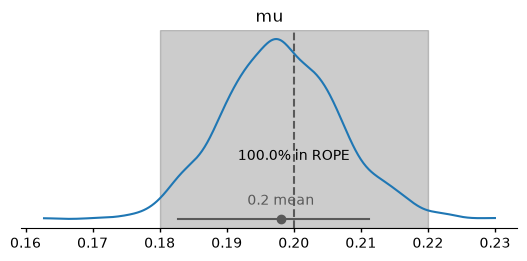

In [14]:
pc = azp.plot_dist(
    idata,
    var_names=["mu"],
    ci_kind="hdi",
    ci_prob=0.90,
    rope=(rope_low, rope_high),
)
azp.add_lines(pc, values=TARGET)
plt.show()


## 8. Group average is not the same as the next person

Even if the **average** montage performance is close to 0.20 V/m, a new participant can be appreciably above or below it. We can use posterior samples of μ and σ to predict the electric field for a new participant.

Sampling: [efield]


Output()

90% posterior predictive interval for a new participant: 0.089 to 0.303 V/m


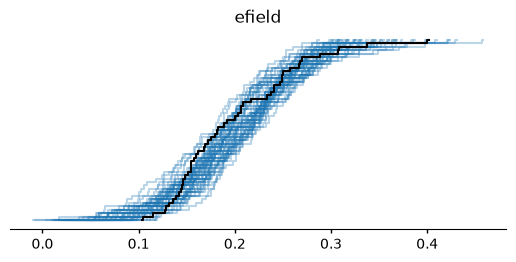

In [15]:
with model:
    pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, extend_inferencedata=True)

ax = azp.plot_ppc_dist(idata, var_names="efield", kind="ecdf")

pp = idata.posterior_predictive["efield"]
pred_hdi90 = azs.hdi(pp, prob=0.90, dim=pp.dims)

low = pred_hdi90.sel(ci_bound="lower").item()
high = pred_hdi90.sel(ci_bound="upper").item()

print(f"90% posterior predictive interval for a new participant: "
      f"{low:.3f} to {high:.3f} V/m")

## 9. Now change something and run the notebook again

Try one change at a time:

- Make your prior interval **much narrower**.
- Make it **much wider**.
- Use only **10 participants**.
- Return to all **53 participants**.
- Change what you count as **practically close enough** to the target.

Notice which parts of the answer are driven mostly by your prior assumptions, which are driven by the amount of data, and which depend on the **scientific question you decided to ask**.

---

## What we will learn to do in the course

This example has only one outcome and one group. In the course we will use the same ideas to ask more interesting questions:

How do I:
- **check my assumptions before I fit the model?**
- **know whether the fitting algorithm converged?**
- **know if the model fits the data?**
- **get an answer to a scientific question?**
- **decide whether an effect is large enough to matter?**
- **model differences between people instead of averaging them away?**
- **decide between different plausible models remain?**

The machinery is relatively straightforward, but it has a lot of power.

As they say: with great power comes great responsibility.